#Capstone 3: Predicting iPSC Donor Differentiation Success

I this project we will use iPSC scRNA-seq data from a dataset of 125 donors to predict endoderm differntiation efficiency. This dataset if from the publication

Cuomo, A.S.E., Seaton, D.D., McCarthy, D.J. *et al.*  
**Single-cell RNA-sequencing of differentiating iPS cells reveals dynamic genetic effects on gene expression.**  
*Nature Communications*, 11, 810 (2020).  
https://doi.org/10.1038/s41467-020-14457-z

The dataset can be dowloaded at: https://zenodo.org/record/3625024#.Xil-0y2cZ0s

The code used in this original publication can be found on Github: https://github.com/single-cell-genetics/singlecell_endodiff_paper/tree/main

##Loading Data

In this notebook we will build a predictive model using the scRNAseq counts from day0 cells (aka iPSCs prior to any differentiation) to predict the definitive endoderm (DE) score. This data can be found in the .h5ad file generated in the previous EDA notebook for this project and stored in the Google Drive foler Capstone3_iPSC_EDA.  There are two different DE scores that can be used as the target label, each with it's own dataset.

DEscore = Score derived from high expression of genes associated with endogenous definitive endoderm cells and low expression of genes associated with iPSCs, made using the `score_genes` function in the ScanPy library.

psuedorank = Score derived from the `psuedotime`, function in the ScanPy library which generates a progression from a randomly chosen day0 cell through the most differentiated cell in the dataset.

We'll start with mounting Google Drive, installing and importing the necessary libraries and loading the data files.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 54.8 gigabytes of available RAM

You are using a high-RAM runtime!


In [3]:
!pip install scanpy anndata seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 76.4 MB/s eta 0:00:00


In [4]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 22.1 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost.sklearn import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr, kendalltau
import shap
from collections import Counter
from catboost import Pool

In [6]:
day0_score = sc.read_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/Capstone3_iPSC_EDA/adata_DEscores_day0.h5ad")

##Convert Day0 data to Pseudobulk

As was shown in the previous notebook, building a predictive model from single cell data was not successfull as the learners focused on the noise in the data.  To address this, we will convert the data to psuedobulk with each donor being one sample.  The standard protocol is to sum the raw counts for each cell from a given donor.

In [8]:
#Code from https://www.youtube.com/watch?v=Ee0PQUwVH8Q
donors = []
for donor in day0_score.obs["donor"].unique():
  donor_day0 = day0_score[day0_score.obs["donor"] == donor].copy()
  donor_day0.X = donor_day0.layers["counts"] #Access the saved raw counts
  donor_rep = sc.AnnData(X = donor_day0.X.sum(axis=0).reshape(1, -1), var = donor_day0.var)
  donor_rep.obs_names = [donor]
  donor_rep.obs['DEscore_long'] = donor_day0.obs['mean_DEscore_long'].iloc[0]  #use our previously creates average scores from the day3 cells
  donor_rep.obs['DEscore_short'] = donor_day0.obs['mean_DEscore_short'].iloc[0]
  donor_rep.obs['pseudorank'] = donor_day0.obs['mean_pseudorank'].iloc[0]
  donors.append(donor_rep)
donor_adata = sc.concat(donors)

In [9]:
donor_day0.X.max()

np.float64(15974.7062116609)

In [10]:
#Verify our new dataset has the expected shape and columns
donor_adata

AnnData object with n_obs × n_vars = 92 × 11231
    obs: 'DEscore_long', 'DEscore_short', 'pseudorank'

In [11]:
#Normalize pseudobulk data
donor_adata.layers['counts'] = donor_adata.X.copy() #Stores raw counts in layer of the adata object so they're not lost during normalization
donor_adata.layers['counts'].max()

np.float64(4477677.06230918)

In [12]:
sc.pp.normalize_total(donor_adata, target_sum=1e4) #Normalize counts
sc.pp.log1p(donor_adata)

In [13]:
donor_adata.layers['counts'].max()

np.float64(4477677.06230918)

##Dimension Reduction

Our current dataset includes counts from about 11,000 genes. To reduce this to a manageable amount for screening models, we will take the top 100 genes with the greatest correlation to DE Score or pseudorank

In [14]:
# Find genes that correlate with DE scores.
y = donor_adata.obs['DEscore_long'].values
corrs = []
for g in donor_adata.var_names:
  x = donor_adata[:, g].X.flatten()
  r, _ = spearmanr(x,y)
  corrs.append(r)
donor_adata.var['corr_DE'] = corrs

In [15]:
# Find genes that correlate with pseudoranks.
y = donor_adata.obs['pseudorank'].values
corrs = []
for g in donor_adata.var_names:
  x = donor_adata[:, g].X.flatten()
  r, _ = spearmanr(x,y)
  corrs.append(r)
donor_adata.var['corr_PR'] = corrs

In [16]:
#Sort donor_adata based on correlation to DE score, collect the 100 genes with the highest correlations
top_genes_score = donor_adata.var['corr_DE'].abs().sort_values(ascending=False).head(100).index

#Sort donor_adata based on correlation to pseudorank, collect the 100 genes with the highest correlations
top_genes_rank = donor_adata.var['corr_PR'].abs().sort_values(ascending=False).head(100).index

#Make new scanpy datasets with only the 100 selected genes correlating with DE_score and pseudorank, respectively
donor_score = donor_adata[:, top_genes_score].copy()
donor_rank = donor_adata[:, top_genes_rank].copy()

##Model Building: Screening Learners

I will test two data set for modelling with regressors, using a tree based approach.

We will try using the 100 individual genes with the greatest correlations with DE score, as this model would remove the necessity of RNAseq to produce future datasets. These datasets are already saved as `donor_score` and `donor_rank`, respectively.


We can start with train, test splits on our final datasets.

Model screening will start with DE score and then we'll test the best learners with pseudorank predictions.

In [17]:
def normalize_log(df):
    arr = df.values
    counts = arr / arr.sum(axis=1, keepdims=True) * 1e4
    zero_rows = df[df.sum(axis=1) == 0]
    return pd.DataFrame(np.log1p(counts), index=df.index, columns=df.columns)

In [18]:
donor_score.layers['counts'].max()

np.float64(3595567.469542)

In [19]:
#For correlating genes, predicting DE score
donor_score.X = donor_score.layers['counts']
X = pd.DataFrame(donor_score.X, columns=donor_score.var_names, index=donor_score.obs_names)
y = donor_score.obs['DEscore_long']

X_train_score, X_test_score, y_train_score, y_test_score = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_score = normalize_log(X_train_score)
X_test_score = normalize_log(X_test_score)

In [20]:
#For correlating genes, predicting pseudorank
donor_rank.X = donor_rank.layers['counts']
X = pd.DataFrame(donor_rank.X, columns=donor_rank.var_names, index=donor_rank.obs_names)
y = donor_rank.obs['pseudorank']

X_train_rank, X_test_rank, y_train_rank, y_test_rank = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_rank = normalize_log(X_train_rank)
X_test_rank = normalize_log(X_test_rank)

####Predicting DE Score

In [21]:
#Run default linear regression on dataset
LR = LinearRegression()
LR.fit(X_train_score, y_train_score)
LR.score(X_train_score, y_train_score)

1.0

In [22]:
#Determine MAE with test data
y_pred_LR = np.array(LR.predict(X_test_score))
mae_LR = mean_absolute_error(y_test_score, y_pred_LR)
mape_LR = mean_absolute_percentage_error(y_test_score, y_pred_LR)
print(f'Linear Regression MAE: {mae_LR}')

Linear Regression MAE: 0.5686019551370249


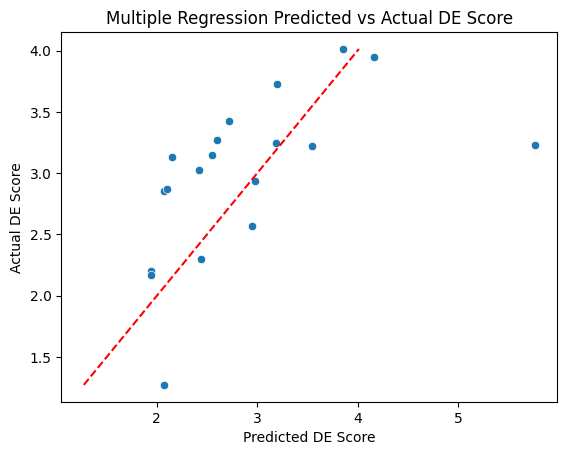

In [23]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_LR, y=y_test_score)

# Add a line for perfect correlation.
plt.plot([y_test_score.min(), y_test_score.max()],
         [y_test_score.min(), y_test_score.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Multiple Regression Predicted vs Actual DE Score')
plt.show()

In [24]:
#Run default Random Forest regression on dataset
RF = RandomForestRegressor()
RF.fit(X_train_score, y_train_score)
RF.score(X_train_score, y_train_score)

0.9271813566491808

In [25]:
#Determine MAE with test data
y_pred_RF = np.array(RF.predict(X_test_score))
y_pred_RF_score_genes = np.array(RF.predict(X_test_score))
mae_RF = mean_absolute_error(y_test_score, y_pred_RF)
mape_RF = mean_absolute_percentage_error(y_test_score, y_pred_RF)
print(f'Random Forest Regression MAE: {mae_RF}')

Random Forest Regression MAE: 0.408408340814673


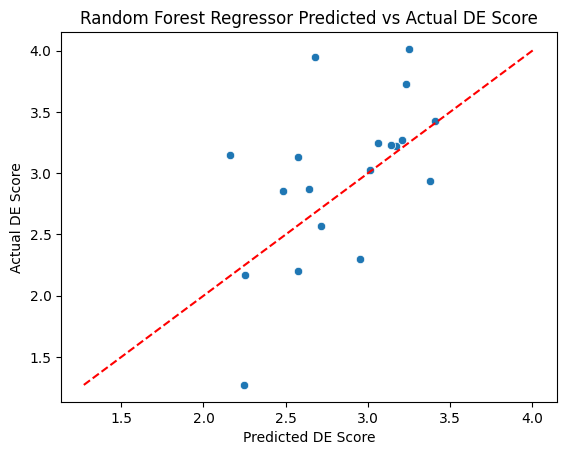

In [26]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_RF, y=y_test_score)

# Add a line for perfect correlation.
plt.plot([y_test_score.min(), y_test_score.max()],
         [y_test_score.min(), y_test_score.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Random Forest Regressor Predicted vs Actual DE Score')
plt.show()

In [27]:
#Run default Grandient Boosting regression on dataset
GB = GradientBoostingRegressor()
GB.fit(X_train_score, y_train_score)
GB.score(X_train_score, y_train_score)

0.9998104749486336

In [28]:
#Determine MAE with test data
y_pred_GB = np.array(GB.predict(X_test_score))
mae_GB = mean_absolute_error(y_test_score, y_pred_GB)
mape_GB = mean_absolute_percentage_error(y_test_score, y_pred_GB)
print(f'Grandient Boosting Regression MAE: {mae_GB}')

Grandient Boosting Regression MAE: 0.3786285841642822


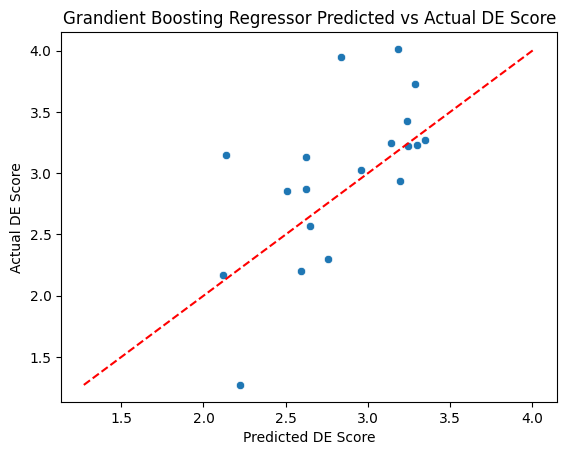

In [29]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_GB, y=y_test_score)

# Add a line for perfect correlation.
plt.plot([y_test_score.min(), y_test_score.max()],
         [y_test_score.min(), y_test_score.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Grandient Boosting Regressor Predicted vs Actual DE Score')
plt.show()

In [30]:
#Run default XGBoost regression on dataset
XG = XGBRegressor()
XG.fit(X_train_score, y_train_score)
XG.score(X_train_score, y_train_score)

0.9999995487400316

In [31]:
#Determine MAE with test data
y_pred_XG = np.array(XG.predict(X_test_score))
mae_XG = mean_absolute_error(y_test_score, y_pred_XG)
mape_XG = mean_absolute_percentage_error(y_test_score, y_pred_XG)
print(f'XGBoost Regression MAE: {mae_XG}')

XGBoost Regression MAE: 0.45687917707028447


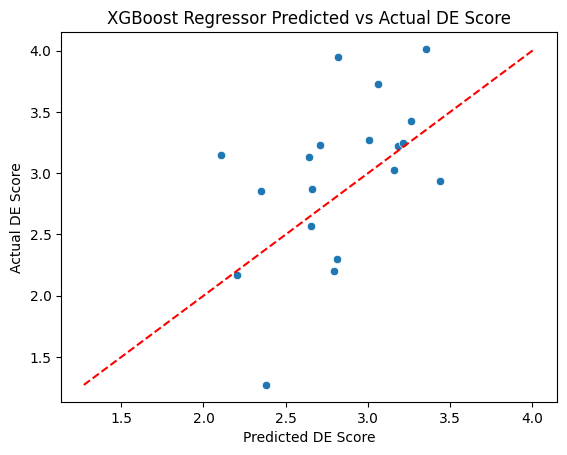

In [32]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_XG, y=y_test_score)

# Add a line for perfect correlation.
plt.plot([y_test_score.min(), y_test_score.max()],
         [y_test_score.min(), y_test_score.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('XGBoost Regressor Predicted vs Actual DE Score')
plt.show()

In [33]:
#Run default CatBoost regression on dataset
CB = CatBoostRegressor()
CB.fit(X_train_score, y_train_score)
CB.score(X_train_score, y_train_score)

Learning rate set to 0.027076
0:	learn: 0.5984708	total: 49.8ms	remaining: 49.8s
1:	learn: 0.5928706	total: 52.7ms	remaining: 26.3s
2:	learn: 0.5867061	total: 55.3ms	remaining: 18.4s
3:	learn: 0.5806490	total: 57.9ms	remaining: 14.4s
4:	learn: 0.5750948	total: 60.3ms	remaining: 12s
5:	learn: 0.5694375	total: 63ms	remaining: 10.4s
6:	learn: 0.5633121	total: 65.6ms	remaining: 9.31s
7:	learn: 0.5568677	total: 68.2ms	remaining: 8.45s
8:	learn: 0.5516420	total: 70.7ms	remaining: 7.79s
9:	learn: 0.5475357	total: 73.3ms	remaining: 7.25s
10:	learn: 0.5414470	total: 75.8ms	remaining: 6.82s
11:	learn: 0.5354946	total: 78.5ms	remaining: 6.46s
12:	learn: 0.5299417	total: 81.1ms	remaining: 6.15s
13:	learn: 0.5243809	total: 83.5ms	remaining: 5.88s
14:	learn: 0.5190025	total: 86.1ms	remaining: 5.65s
15:	learn: 0.5140561	total: 88.8ms	remaining: 5.46s
16:	learn: 0.5086133	total: 91.3ms	remaining: 5.28s
17:	learn: 0.5043724	total: 93.8ms	remaining: 5.12s
18:	learn: 0.4999926	total: 96.4ms	remaining: 4.

np.float64(0.9999985119212258)

In [34]:
#Determine MAE with test data
y_pred_CB = np.array(CB.predict(X_test_score))
y_pred_CB_score_genes = np.array(CB.predict(X_test_score))
mae_CB = mean_absolute_error(y_test_score, y_pred_CB)
mape_CB = mean_absolute_percentage_error(y_test_score, y_pred_CB)
print(f'Grandient Boosting Regression MAE: {mae_CB}')

Grandient Boosting Regression MAE: 0.4100108137393179


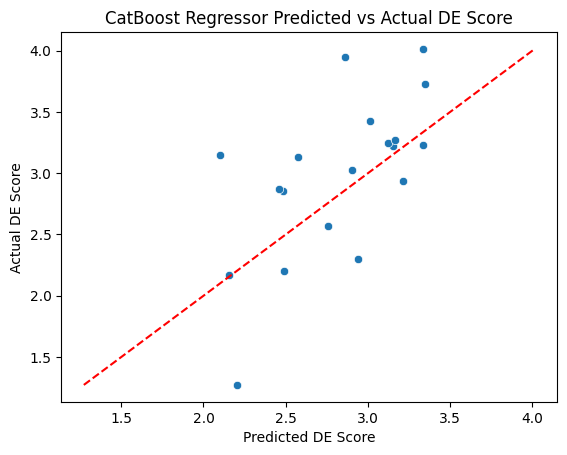

In [35]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_CB, y=y_test_score)

# Add a line for perfect correlation.
plt.plot([y_test_score.min(), y_test_score.max()],
         [y_test_score.min(), y_test_score.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('CatBoost Regressor Predicted vs Actual DE Score')
plt.show()

In [36]:
MAE_dict = {'Multiple Linear Regression': mae_LR, 'Random Forest Regressor': mae_RF, 'Gradient Boost Regressor': mae_GB, 'XGBoost Regressor': mae_XG, 'CatBoost Regressor': mae_CB}
MAPE_dict = {'Multiple Linear Regression': mape_LR, 'Random Forest Regressor': mape_RF, 'Gradient Boost Regressor': mape_GB, 'XGBoost Regressor': mape_XG, 'CatBoost Regressor': mape_CB}
Rsquared_dict = {'Multiple Linear Regression': LR.score(X_train_score, y_train_score), 'Random Forest Regressor': RF.score(X_train_score, y_train_score), 'Gradient Boost Regressor': GB.score(X_train_score, y_train_score),
                 'XGBoost Regressor': XG.score(X_train_score, y_train_score), 'CatBoost Regressor': CB.score(X_train_score, y_train_score)}
summary_genes_score = pd.DataFrame({'MAE': MAE_dict, 'MAPE': MAPE_dict, 'R²': Rsquared_dict})
summary_genes_score

,MAE,MAPE,R²
Multiple Linear Regression,0.568602,0.204038,1.000000
Random Forest Regressor,0.408408,0.154622,0.927181
Gradient Boost Regressor,0.378629,0.142984,0.999810
XGBoost Regressor,0.456879,0.173794,1.000000
CatBoost Regressor,0.410011,0.153956,0.999999


####Predicting Pseudorank

In [37]:
#Run default linear regression on dataset
LR = LinearRegression()
LR.fit(X_train_rank, y_train_rank)
LR.score(X_train_rank, y_train_rank)

1.0

In [38]:
#Determine MAE with test data
y_pred_LR = np.array(LR.predict(X_test_rank))
mae_LR = mean_absolute_error(y_test_rank, y_pred_LR)
mape_LR = mean_absolute_percentage_error(y_test_rank, y_pred_LR)
print(f'Linear Regression MAE: {mae_LR}')

Linear Regression MAE: 0.04734697500009018


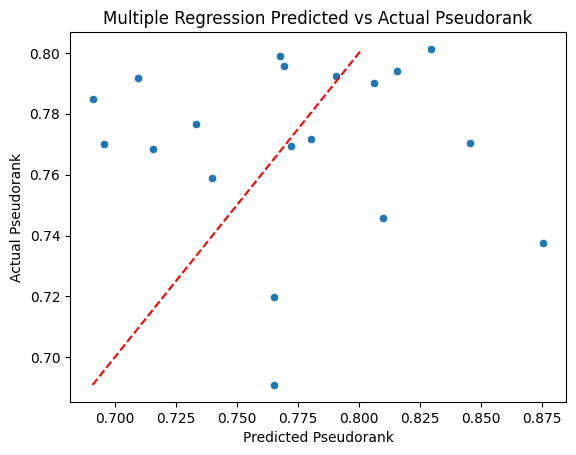

In [39]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_LR, y=y_test_rank)

# Add a line for perfect correlation.
plt.plot([y_test_rank.min(), y_test_rank.max()],
         [y_test_rank.min(), y_test_rank.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Multiple Regression Predicted vs Actual Pseudorank')
plt.show()

In [40]:
#Run default Random Forest regression on dataset
RF = RandomForestRegressor()
RF.fit(X_train_rank, y_train_rank)
RF.score(X_train_rank, y_train_rank)

0.927515779217058

In [41]:
#Determine MAE with test data
y_pred_RF = np.array(RF.predict(X_test_rank))
y_pred_RF_rank_genes = np.array(RF.predict(X_test_rank))
mae_RF = mean_absolute_error(y_test_rank, y_pred_RF)
mape_RF = mean_absolute_percentage_error(y_test_rank, y_pred_RF)
print(f'Random Forest Regression MAE: {mae_RF}')

Random Forest Regression MAE: 0.01614011353568027


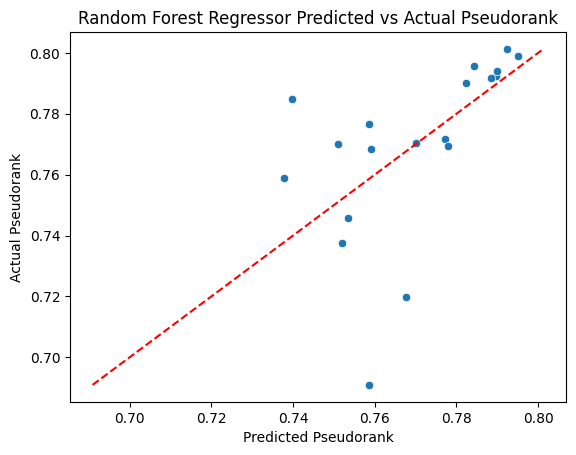

In [42]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_RF, y=y_test_rank)

# Add a line for perfect correlation.
plt.plot([y_test_rank.min(), y_test_rank.max()],
         [y_test_rank.min(), y_test_rank.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Random Forest Regressor Predicted vs Actual Pseudorank')
plt.show()

In [43]:
#Run default Grandient Boosting regression on dataset
GB = GradientBoostingRegressor()
GB.fit(X_train_rank, y_train_rank)
GB.score(X_train_rank, y_train_rank)

0.9999015030196474

In [44]:
#Determine MAE with test data
y_pred_GB = np.array(GB.predict(X_test_rank))
mae_GB = mean_absolute_error(y_test_rank, y_pred_GB)
mape_GB = mean_absolute_percentage_error(y_test_rank, y_pred_GB)
print(f'Grandient Boosting Regression MAE: {mae_GB}')

Grandient Boosting Regression MAE: 0.01609575132549047


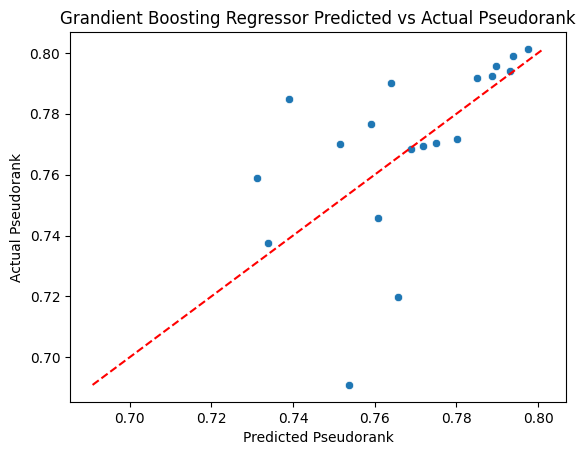

In [45]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_GB, y=y_test_rank)

# Add a line for perfect correlation.
plt.plot([y_test_rank.min(), y_test_rank.max()],
         [y_test_rank.min(), y_test_rank.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Grandient Boosting Regressor Predicted vs Actual Pseudorank')
plt.show()

In [46]:
#Run default XGBoost regression on dataset
XG = XGBRegressor()
XG.fit(X_train_rank, y_train_rank)
XG.score(X_train_rank, y_train_rank)

0.9997801780700684

In [47]:
#Determine MAE with test data
y_pred_XG = np.array(XG.predict(X_test_rank))
mae_XG = mean_absolute_error(y_test_rank, y_pred_XG)
mape_XG = mean_absolute_percentage_error(y_test_rank, y_pred_XG)
print(f'XGBoost Regression MAE: {mae_XG}')

XGBoost Regression MAE: 0.01685868762433529


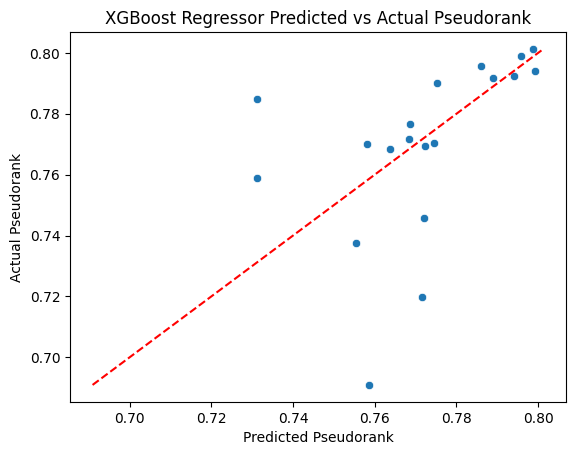

In [48]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_XG, y=y_test_rank)

# Add a line for perfect correlation.
plt.plot([y_test_rank.min(), y_test_rank.max()],
         [y_test_rank.min(), y_test_rank.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('XGBoost Regressor Predicted vs Actual Pseudorank')
plt.show()

In [49]:
#Run default CatBoost regression on dataset
CB = CatBoostRegressor()
CB.fit(X_train_rank, y_train_rank)
CB.score(X_train_rank, y_train_rank)

Learning rate set to 0.027076
0:	learn: 0.0246489	total: 4.78ms	remaining: 4.78s
1:	learn: 0.0243869	total: 7.2ms	remaining: 3.59s
2:	learn: 0.0241063	total: 9.93ms	remaining: 3.3s
3:	learn: 0.0238328	total: 12.2ms	remaining: 3.04s
4:	learn: 0.0235860	total: 14.5ms	remaining: 2.88s
5:	learn: 0.0233472	total: 16.8ms	remaining: 2.77s
6:	learn: 0.0231121	total: 19.7ms	remaining: 2.79s
7:	learn: 0.0228588	total: 22.5ms	remaining: 2.79s
8:	learn: 0.0226409	total: 25.7ms	remaining: 2.83s
9:	learn: 0.0224257	total: 28.1ms	remaining: 2.78s
10:	learn: 0.0222464	total: 30.5ms	remaining: 2.74s
11:	learn: 0.0220215	total: 33.9ms	remaining: 2.79s
12:	learn: 0.0218468	total: 36.5ms	remaining: 2.77s
13:	learn: 0.0216180	total: 39ms	remaining: 2.75s
14:	learn: 0.0213930	total: 41.5ms	remaining: 2.73s
15:	learn: 0.0211503	total: 43.8ms	remaining: 2.69s
16:	learn: 0.0209749	total: 46.5ms	remaining: 2.69s
17:	learn: 0.0207750	total: 48.9ms	remaining: 2.67s
18:	learn: 0.0205620	total: 51.3ms	remaining: 2.

np.float64(0.9999989590169746)

In [50]:
#Determine MAE with test data
y_pred_CB = np.array(CB.predict(X_test_rank))
y_pred_CB_rank_genes = np.array(CB.predict(X_test_rank))
mae_CB = mean_absolute_error(y_test_rank, y_pred_CB)
mape_CB = mean_absolute_percentage_error(y_test_rank, y_pred_CB)
print(f'Grandient Boosting Regression MAE: {mae_CB}')

Grandient Boosting Regression MAE: 0.015048846789612469


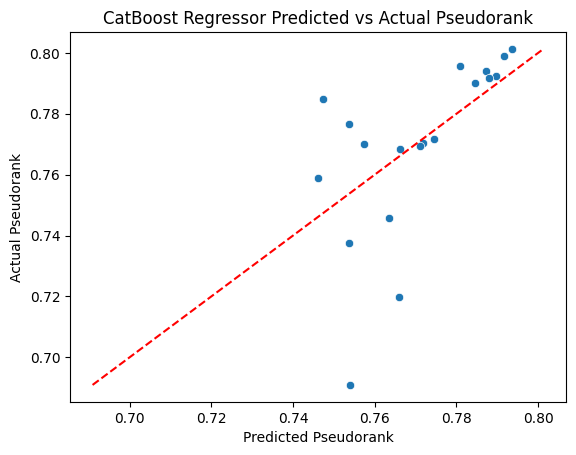

In [51]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_CB, y=y_test_rank)

# Add a line for perfect correlation.
plt.plot([y_test_rank.min(), y_test_rank.max()],
         [y_test_rank.min(), y_test_rank.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('CatBoost Regressor Predicted vs Actual Pseudorank')
plt.show()

In [52]:
MAE_dict = {'Multiple Linear Regression': mae_LR, 'Random Forest Regressor': mae_RF, 'Gradient Boost Regressor': mae_GB, 'XGBoost Regressor': mae_XG, 'CatBoost Regressor': mae_CB}
MAPE_dict = {'Multiple Linear Regression': mape_LR, 'Random Forest Regressor': mape_RF, 'Gradient Boost Regressor': mape_GB, 'XGBoost Regressor': mape_XG, 'CatBoost Regressor': mape_CB}
Rsquared_dict = {'Multiple Linear Regression': LR.score(X_train_rank, y_train_rank), 'Random Forest Regressor': RF.score(X_train_rank, y_train_rank), 'Gradient Boost Regressor': GB.score(X_train_rank, y_train_rank),
                 'XGBoost Regressor': XG.score(X_train_rank, y_train_rank), 'CatBoost Regressor': CB.score(X_train_rank, y_train_rank)}
summary_genes_rank = pd.DataFrame({'MAE': MAE_dict, 'MAPE': MAPE_dict, 'R²': Rsquared_dict})
summary_genes_rank

,MAE,MAPE,R²
Multiple Linear Regression,0.047347,0.062277,1.000000
Random Forest Regressor,0.016140,0.021641,0.927516
Gradient Boost Regressor,0.016096,0.021510,0.999902
XGBoost Regressor,0.016859,0.022656,0.999780
CatBoost Regressor,0.015049,0.020189,0.999999


####Summary of Model Screening

In [53]:
summary_merged = pd.concat([summary_genes_score.add_prefix('genes_DE_'),
                            summary_genes_rank.add_prefix('genes_PR_')], axis=1)

summary_merged

,genes_DE_MAE,genes_DE_MAPE,genes_DE_R²,genes_PR_MAE,genes_PR_MAPE,genes_PR_R²
Multiple Linear Regression,0.568602,0.204038,1.000000,0.047347,0.062277,1.000000
Random Forest Regressor,0.408408,0.154622,0.927181,0.016140,0.021641,0.927516
Gradient Boost Regressor,0.378629,0.142984,0.999810,0.016096,0.021510,0.999902
XGBoost Regressor,0.456879,0.173794,1.000000,0.016859,0.022656,0.999780
CatBoost Regressor,0.410011,0.153956,0.999999,0.015049,0.020189,0.999999


The above summary table has a lot of information, so I'll make a smaller tables for the MAE and MAPE to help with comparisons.  The R2 values are pretty consisttent accross learners, so we will leave those for now.

In [54]:
summary_merged_MAE = summary_merged[['genes_DE_MAE', 'genes_PR_MAE']]
summary_merged_MAE

,genes_DE_MAE,genes_PR_MAE
Multiple Linear Regression,0.568602,0.047347
Random Forest Regressor,0.408408,0.016140
Gradient Boost Regressor,0.378629,0.016096
XGBoost Regressor,0.456879,0.016859
CatBoost Regressor,0.410011,0.015049


From this summary of MAE, we learn the following:

1) MAE for PR predictions are way lower than for DE predictions.  This is partly due to the different scales between PR and DE, with DE being about 5x higher that PR, but the difference between MAE is closer to 20x.  We'll use MAPE to better compare predictions of PR and DE.
2) Best Learners: CatBoost, but it can vary by split.

Note: I ran the model screening with a few different splits by changing the ranndom state seed and the MAE differneces between best learners (excluding Multiple Regression) are smaller than the MAE diffences with the same learner working with different splits (more on this below).  CatBoost genes_PR_MAE varied from 0.022 to 0.009 with my tests.  Random Forest and CatBoost were usually the best, but not every time.

In [55]:
summary_merged_MAPE = summary_merged[['genes_DE_MAPE', 'genes_PR_MAPE']]
summary_merged_MAPE

,genes_DE_MAPE,genes_PR_MAPE
Multiple Linear Regression,0.204038,0.062277
Random Forest Regressor,0.154622,0.021641
Gradient Boost Regressor,0.142984,0.021510
XGBoost Regressor,0.173794,0.022656
CatBoost Regressor,0.153956,0.020189


From this summary of MAPE, we learn the following:

1) We confirm that predictions from PR are better than predictions from DE, as a percentage of the target values.  MAPE for DE is 5-10x higher than for PR.
2) Best Learners overall: Random Forest and CatBoost using genes to predict PR.

Another approach to evaluating these models is to see how their predictions rank the donors relative to the actual order.  The most plausible 'real world' application of this type of model would be to select the top 5-10 donors for for validation in the lab.  We will look at this in the next section.

##Assessing Donor Order

To visualize this donor ranking, I'll use a slope chart comparing actual donor order to the new order based on predictions using Random Forest and CatBoost predictions from gene datasets.

In [56]:
donor_order_RF = pd.DataFrame({'actual_pr':y_test_rank,
                               'actual_de':y_test_score,
                               'pred_rank_genes':pd.Series(y_pred_RF_rank_genes, index=y_test_rank.index),
                               'pred_score_genes':pd.Series(y_pred_RF_score_genes, index=y_test_score.index)})
donor_order_CB = pd.DataFrame({'actual_pr':y_test_rank,
                               'actual_de':y_test_score,
                               'pred_rank_genes':pd.Series(y_pred_CB_rank_genes, index=y_test_rank.index),
                               'pred_score_genes':pd.Series(y_pred_CB_score_genes, index=y_test_score.index)})
donor_order_RF.head()

,actual_pr,actual_de,pred_rank_genes,pred_score_genes
rayr,0.792530,3.218158,0.789725,3.168233
vazt,0.737484,3.227794,0.752102,3.138428
yelp,0.798859,2.939669,0.795041,3.379139
iiyk,0.768312,2.857949,0.759168,2.485400
zapk,0.719840,2.296221,0.767704,2.952426


In [57]:
donor_order_rank = pd.DataFrame({'actual_pr':y_test_rank,
                                 'pred_RF':pd.Series(y_pred_RF_rank_genes, index=y_test_rank.index),
                                 'pred_CB':pd.Series(y_pred_CB_rank_genes, index=y_test_rank.index)})
donor_order_score = pd.DataFrame({'actual_de':y_test_score,
                               'pred_RF':pd.Series(y_pred_RF_score_genes, index=y_test_score.index),
                               'pred_CB':pd.Series(y_pred_CB_score_genes, index=y_test_score.index)})
donor_order_rank.head()

,actual_pr,pred_RF,pred_CB
rayr,0.792530,0.789725,0.789651
vazt,0.737484,0.752102,0.753733
yelp,0.798859,0.795041,0.791750
iiyk,0.768312,0.759168,0.766267
zapk,0.719840,0.767704,0.765984


In [58]:
def slope_chart(data, left_col, right_col, title):
  left=data[left_col].dropna()
  right=data[right_col].dropna()
  donors=data.dropna().index
  fig, ax = plt.subplots(figsize=(6,8))
  for donor in donors:
    ax.plot([0,1],[left.loc[donor], right.loc[donor]], marker='o', linewidth=1)
  ax.set_xticks([0,1])
  ax.set_xticklabels([left_col, right_col])
  ax.set_xlim(-0.1,1.1)
  ax.invert_yaxis()
  ax.set_ylabel('Rank')
  ax.set_title(title)
  plt.tight_layout()
  plt.show()

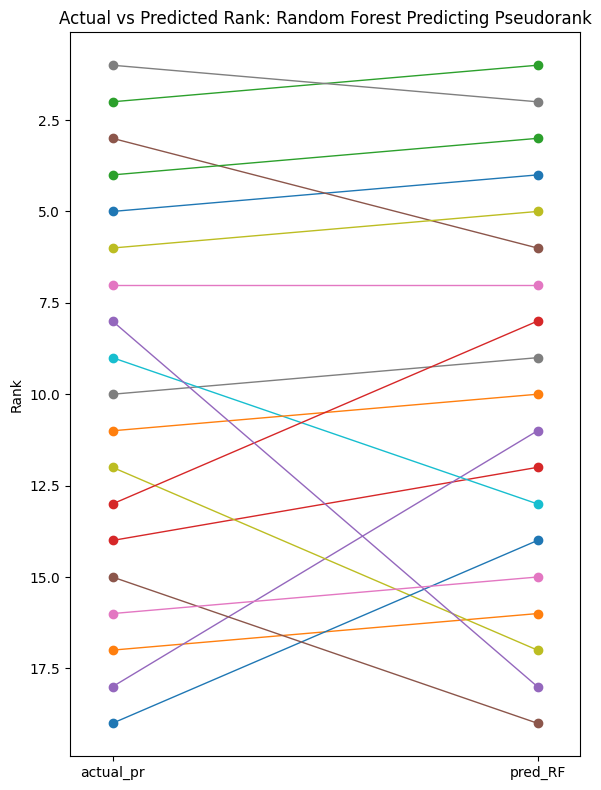

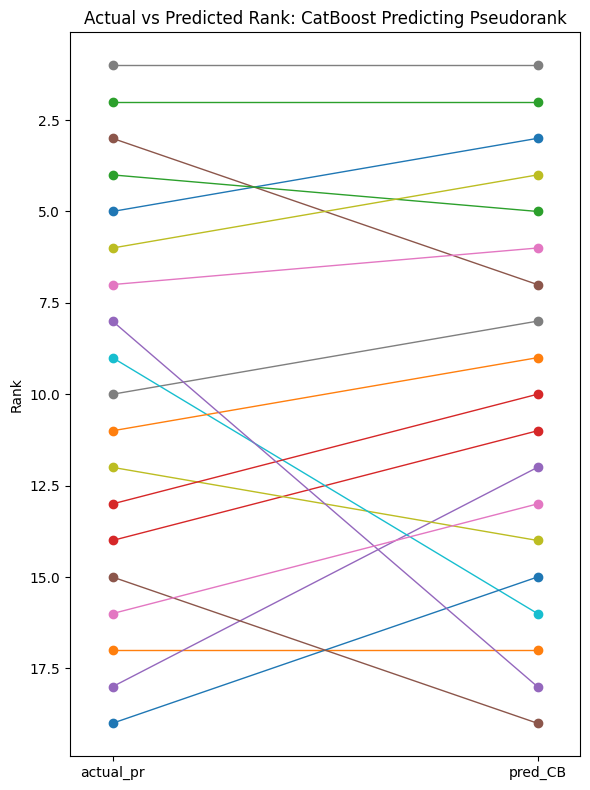

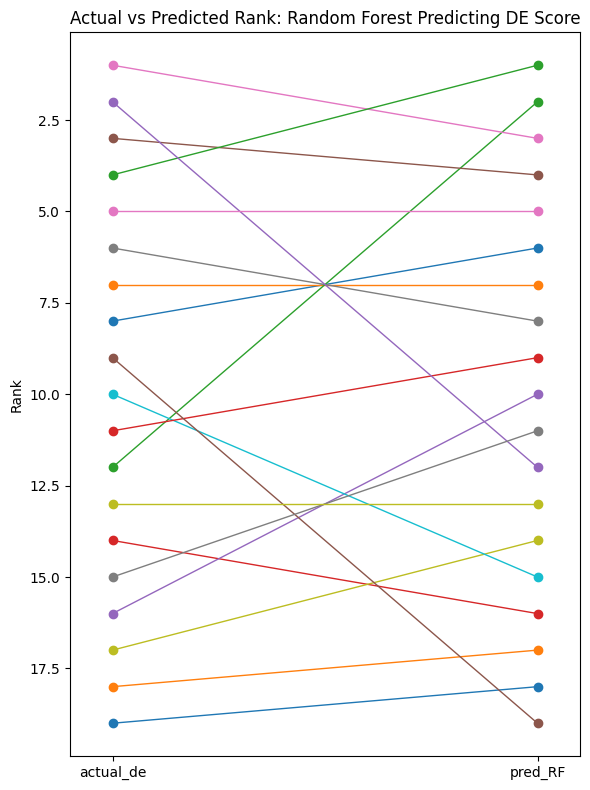

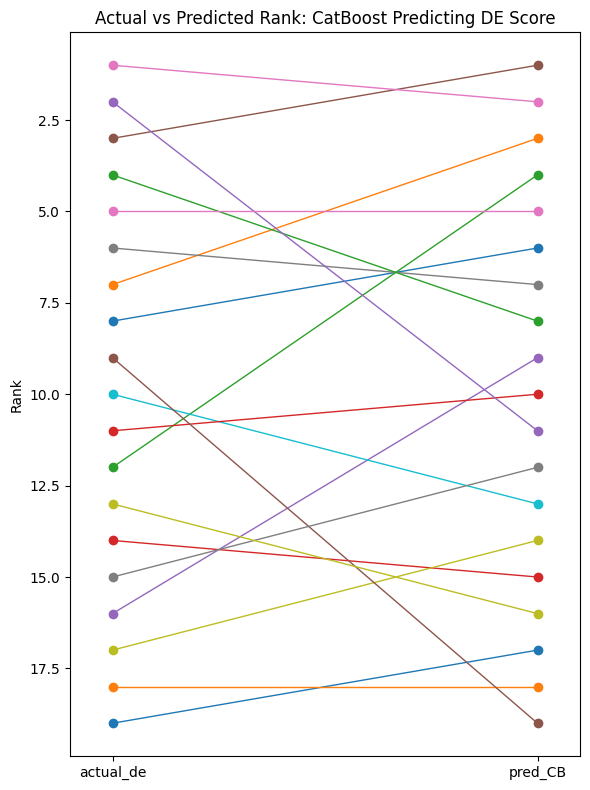

In [59]:
rank_PR = donor_order_rank.rank(ascending=False)
rank_DE = donor_order_score.rank(ascending=False)

slope_chart(rank_PR, 'actual_pr', 'pred_RF', 'Actual vs Predicted Rank: Random Forest Predicting Pseudorank')
slope_chart(rank_PR, 'actual_pr', 'pred_CB', 'Actual vs Predicted Rank: CatBoost Predicting Pseudorank')
slope_chart(rank_DE, 'actual_de', 'pred_RF', 'Actual vs Predicted Rank: Random Forest Predicting DE Score')
slope_chart(rank_DE, 'actual_de', 'pred_CB', 'Actual vs Predicted Rank: CatBoost Predicting DE Score')

These look pretty good - all four are to pull out the best donors and get the correct order at the top of our list.  Next, I'll look at some statistical metrics of these ranking systems.

In [60]:
def compare_ranks(data1, data2):
  spearman = spearmanr(data1, data2).statistic
  tau = kendalltau(data1, data2).statistic
  mean_rank_error = (data1 - data2).abs().mean()
  return spearman, tau, mean_rank_error

def top_five_overlap(data1, data2):
  top_five_actual = set(data1.nsmallest(5).index)
  top_five_predicted = set(data2.nsmallest(5).index)
  common = top_five_actual.intersection(top_five_predicted)
  return common

def top_three_overlap(data1, data2):
  top_three_actual = set(data1.nsmallest(3).index)
  top_three_predicted = set(data2.nsmallest(3).index)
  common = top_three_actual.intersection(top_three_predicted)
  return common

In [61]:
print(top_five_overlap(rank_PR['actual_pr'], rank_PR['pred_RF']),
      top_five_overlap(rank_PR['actual_pr'], rank_PR['pred_CB']),
      top_five_overlap(rank_DE['actual_de'], rank_DE['pred_RF']),
      top_five_overlap(rank_DE['actual_de'], rank_DE['pred_CB']))

{'rayr', 'zagm', 'hegp', 'yelp'} {'rayr', 'zagm', 'hegp', 'yelp'} {'zagm', 'aowh', 'tolg', 'sohd'} {'aowh', 'tolg', 'sohd'}


In [62]:
print(top_three_overlap(rank_PR['actual_pr'], rank_PR['pred_RF']),
      top_three_overlap(rank_PR['actual_pr'], rank_PR['pred_CB']),
      top_three_overlap(rank_DE['actual_de'], rank_DE['pred_RF']),
      top_three_overlap(rank_DE['actual_de'], rank_DE['pred_CB']))

{'hegp', 'yelp'} {'hegp', 'yelp'} {'tolg'} {'aowh', 'tolg'}


This tells us that the models predicting PR are able to find 4 of the top 5 donors correctly. Finding the top three is less reliable, but Catboost did a better job at this than Random Forest.  CatBoost predicting PR found 2 of the top 3.  This suggests that models would succeed at getting the right donors selected for validation in the lab. Models predicting DE were less accurate.

In [63]:
spearman, tau, mean_rank_error = compare_ranks(rank_PR['actual_pr'], rank_PR['pred_RF'])
print(f'Random Forest ranking of Psueodorank - Spearman: {spearman}')
print(f'Random Forest ranking of Psueodorank - Kendall Tau: {tau}')
print(f'Random Forest ranking of Psueodorank - Mean Rank Error: {mean_rank_error}')

Random Forest ranking of Psueodorank - Spearman: 0.756140350877193
Random Forest ranking of Psueodorank - Kendall Tau: 0.5789473684210525
Random Forest ranking of Psueodorank - Mean Rank Error: 2.8421052631578947


In [64]:
spearman, tau, mean_rank_error = compare_ranks(rank_PR['actual_pr'], rank_PR['pred_CB'])
print(f'CatBoost ranking of Psueodorank - Spearman: {spearman}')
print(f'CatBoost ranking of Psueodorank - Kendall Tau: {tau}')
print(f'CatBoost ranking of Psueodorank - Mean Rank Error: {mean_rank_error}')

CatBoost ranking of Psueodorank - Spearman: 0.7526315789473684
CatBoost ranking of Psueodorank - Kendall Tau: 0.5906432748538012
CatBoost ranking of Psueodorank - Mean Rank Error: 2.9473684210526314


In [65]:
spearman, tau, mean_rank_error = compare_ranks(rank_DE['actual_de'], rank_DE['pred_RF'])
print(f'Random Forest ranking of DE Score - Spearman: {spearman}')
print(f'Random Forest ranking of DE Score - Kendall Tau: {tau}')
print(f'Random Forest ranking of DE Score - Mean Rank Error: {mean_rank_error}')

Random Forest ranking of DE Score - Spearman: 0.6333333333333333
Random Forest ranking of DE Score - Kendall Tau: 0.48538011695906425
Random Forest ranking of DE Score - Mean Rank Error: 3.3684210526315788


In [66]:
spearman, tau, mean_rank_error = compare_ranks(rank_DE['actual_de'], rank_DE['pred_CB'])
print(f'CatBoost ranking of DE Score - Spearman: {spearman}')
print(f'CatBoost ranking of DE Score - Kendall Tau: {tau}')
print(f'CatBoost ranking of DE Score - Mean Rank Error: {mean_rank_error}')

CatBoost ranking of DE Score - Spearman: 0.6684210526315789
CatBoost ranking of DE Score - Kendall Tau: 0.4619883040935673
CatBoost ranking of DE Score - Mean Rank Error: 3.3684210526315788


The above metrics look at the ranking over the entire test set, not just the top. Here again, the models predicting PR do better than models predicting DE.  The Random Forest and CatBoost learners places donors an average of 2.5 ranks away from their actual rank and got the top two donors correct.  However, CatBoost had slightly better Spearman and Kendall Coefficients and did better at ordering donors over different splits (data not show, done by changing the random state seed and running multiple times) lead us to select CatBoost as our learner for the final model.

##Model Building: Final Steps

I the previous section, we selected the CatBoost learner, prediciting donor pseudorank as our preffered model.  We have selected hot to do Hyperparameter tuning as the risk of overfitting outweights the potential benefit of moderate improvements to the existing model.

As a final step, we will refine out features selection.  The existing model was made from the top 100 genes correlating with donor pseudorank. In the following we will optimize gene number, starting from the top 200 genes.

### With CB selection

Instead of selecting genes based on a linear correlation with pseudorank, it is better practice to select features using a tree based model.  Here we will use CatBoost Rgressor to pick out the best 100 genes in place of the dataset we created earlier and see if this improves our model.



In [67]:
#To verify that the donor_adata.layers['counts'] are still the raw counts, find the max value (should be large)
donor_adata.layers['counts'].max()

np.float64(4477677.06230918)

In [68]:
donor_adata.X = donor_adata.layers['counts']
X = pd.DataFrame(donor_adata.X, columns=donor_adata.var_names, index=donor_adata.obs_names)
y_pr = donor_adata.obs['pseudorank']

X_train, X_test, y_train_pr, y_test_pr = train_test_split(X, y_pr, test_size=0.2, random_state=42)
X_train = normalize_log(X_train)
X_test = normalize_log(X_test)

In [69]:
CB_full = CatBoostRegressor(verbose=0)
CB_full.fit(X_train, y_train_pr)
y_pred_full = CB_full.predict(X_test)
import shap

explainer = shap.TreeExplainer(CB_full)
shap_values = explainer.shap_values(X_train)

shap_importance = np.abs(shap_values).mean(axis=0)
shap_rank = pd.Series(shap_importance, index=X_train.columns).sort_values(ascending=False)

In [70]:
# Loop through features lists of the top 50 to 100 features to determine how many features are needed to maintain MAE in the Random Forest learner.
MAE_full = []
for i in range(5, 101, 5):
    X_train_short = X_train[shap_rank.index[:i]]
    X_test_short = X_test[shap_rank.index[:i]]
    CB_short = CatBoostRegressor(verbose=0)
    CB_short.fit(X_train_short, y_train_pr)
    y_pred_CBshort = CB_short.predict(X_test_short)
    y_pred_CBshort=np.asarray(y_pred_CBshort).ravel()
    mae_short = mean_absolute_error(y_test_pr, y_pred_CBshort)
    MAE_full.append(mae_short)

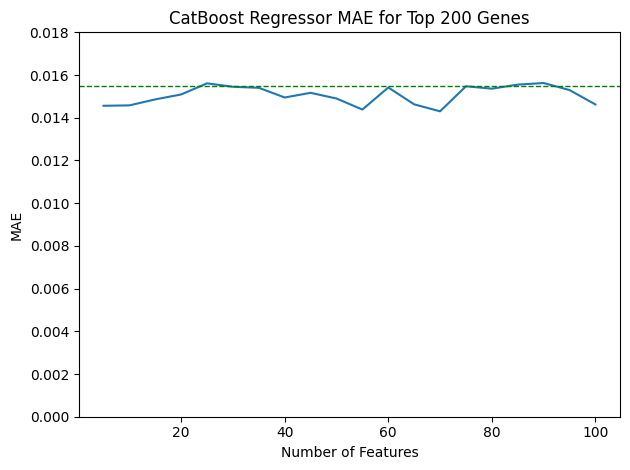

In [71]:
features = range(5, 101, 5)
summary_features = pd.DataFrame({'MAE':MAE_full}, index=features)
sns.lineplot(data=summary_features, x=features, y='MAE')
plt.title('CatBoost Regressor MAE for Top 200 Genes')
plt.xlabel('Number of Features')
plt.ylabel('MAE')
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.ylim(ymin=0, ymax=0.018)
plt.tight_layout()
plt.show()

These models all have an error around what we found with our 100 correlating genes, but there seems to be a lower error with smaller features numbers.  I'll repeat this with 1-20 features.

In [72]:
# Loop through features lists of the top 1 to 20 features to determine how many features are needed to maintain MAE in the CatBoost learner.
MAE_short = []
for i in range(1, 21, 1):
    X_train_short = X_train[shap_rank.index[:i]]
    X_test_short = X_test[shap_rank.index[:i]]
    CB_short = CatBoostRegressor(verbose=0)
    CB_short.fit(X_train_short, y_train_pr)
    y_pred_CBshort = CB_short.predict(X_test_short)
    y_pred_CBshort=np.asarray(y_pred_CBshort).ravel()
    mae_short = mean_absolute_error(y_test_pr, y_pred_CBshort)
    MAE_short.append(mae_short)

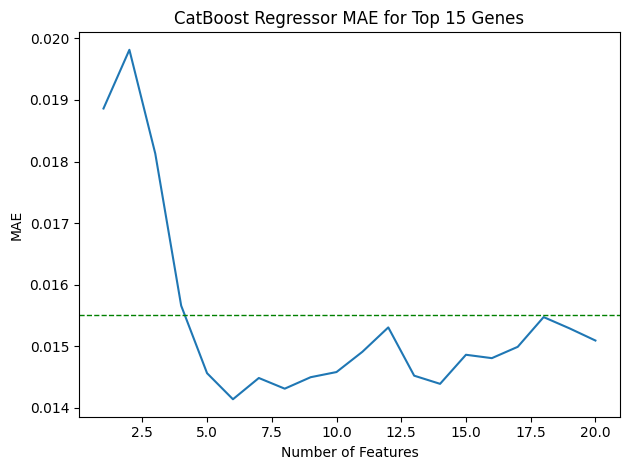

In [73]:
features_short = range(1, 21, 1)
summary_short = pd.DataFrame({'MAE':MAE_short}, index=features_short)

sns.lineplot(data=summary_short, x=features_short, y='MAE')
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.title('CatBoost Regressor MAE for Top 15 Genes')
plt.xlabel('Number of Features')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

This gives us a better idea of what is going on - the lowest MAE is 5-7 genes.  The error is consistently lower than we saw with our previous gene list (although I did have splits that got a lower error). Let's make a new dataset with the top 100 genes and do feature selection over multiple splits.

In [74]:
shap_rank_100 = shap_rank[0:100]
donor_rank_100 = donor_adata[:, shap_rank_100.index].copy()

###Feature Refinement Using Optimized Set of 100 genes

As the attempt with gene selection using a model to pick from the list of 11,000 was unsuccessful, we will go back to our gene lists based on correlation and try to further refine our feature selection.


In [75]:
#To verify that the donor_rank_100.layers['counts'] are still the raw counts, find the max value (should be large)
donor_rank_100.layers['counts'].max()

np.float64(759411.0718874728)

In [76]:
#Redo the split on this 'new' dataset
donor_rank_100.X = donor_rank_100.layers['counts'].copy()
X = pd.DataFrame(donor_rank_100.X, columns=donor_rank_100.var_names, index=donor_rank_100.obs_names)
y_pr = donor_adata.obs['pseudorank']

X_train, X_test, y_train_pr, y_test_pr = train_test_split(X, y_pr, test_size=0.2, random_state=42)
X_train = normalize_log(X_train)
X_test = normalize_log(X_test)

In [77]:
CB_100 = CatBoostRegressor(verbose=0)
CB_100.fit(X_train, y_train_pr)
y_pred_100 = CB_100.predict(X_test)
importances = CB_100.get_feature_importance() #Get feature importances
CB_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False) #Sort genes in order of importance

In [78]:
# Loop through features lists of the top 5 to 100 features to determine how many features are needed to maintain MAE in the Random Forest learner.
MAE_100 = []
for i in range(5, 101, 5):
    X_train_short = X_train[CB_importances.index[:i]]
    X_test_short = X_test[CB_importances.index[:i]]
    CB_short = CatBoostRegressor(verbose=0)
    CB_short.fit(X_train_short, y_train_pr)
    y_pred_CBshort = CB_short.predict(X_test_short)
    y_pred_CBshort=np.asarray(y_pred_CBshort).ravel()
    mae_short = mean_absolute_error(y_test_pr, y_pred_CBshort)
    MAE_100.append(mae_short)

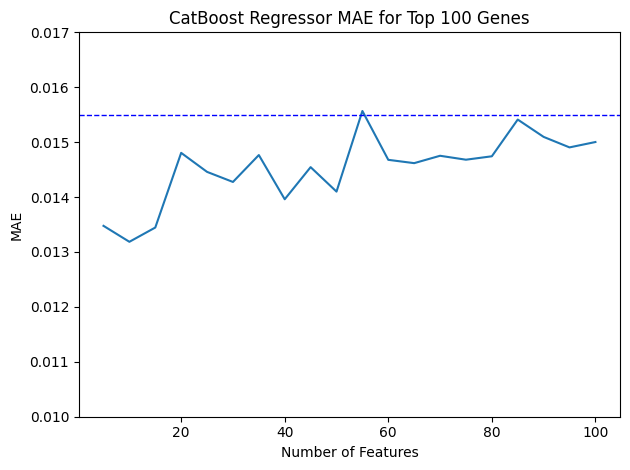

In [79]:
features = range(5, 101, 5)
summary_features = pd.DataFrame({'MAE':MAE_100}, index=features)

sns.lineplot(data=summary_features, x=features, y='MAE')
plt.axhline(y=0.0155, color='blue', linestyle='--', linewidth=1)
plt.title('CatBoost Regressor MAE for Top 100 Genes')
plt.xlabel('Number of Features')
plt.ylim(ymin=.010, ymax=0.017)
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

Our error is essentially the same as our MAE for model screening. This looks like wer are past the plateau phase, so I'll repeat this with smaller numbers of genes.

In [80]:
# Loop through features lists of the top 50 to 1000 features to determine how many features are needed to maintain MAE in the Random Forest learner.
MAE_short = []
for i in range(1, 21, 1):
    X_train_short = X_train[CB_importances.index[:i]]
    X_test_short = X_test[CB_importances.index[:i]]
    CB_short = CatBoostRegressor(verbose=0)
    CB_short.fit(X_train_short, y_train_pr)
    y_pred_CBshort = CB_short.predict(X_test_short)
    y_pred_CBshort=np.asarray(y_pred_CBshort).ravel()
    mae_short = mean_absolute_error(y_test_pr, y_pred_CBshort)
    MAE_short.append(mae_short)

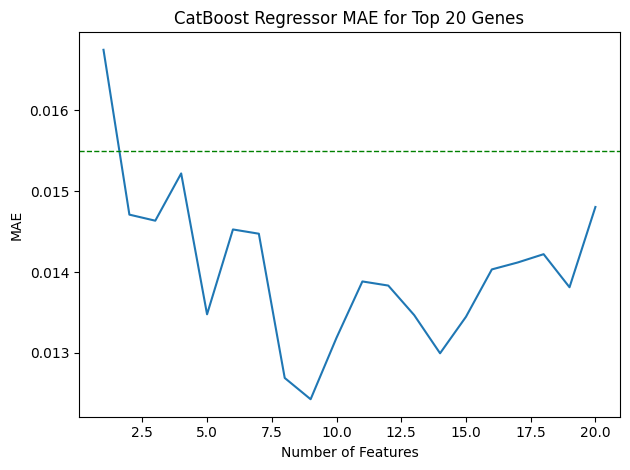

In [81]:
features_short = range(1, 21, 1)
summary_short = pd.DataFrame({'MAE':MAE_short}, index=features_short)

sns.lineplot(data=summary_short, x=features_short, y='MAE')
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.title('CatBoost Regressor MAE for Top 20 Genes')
plt.xlabel('Number of Features')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

With this split, the lowest error is with a model built on the top 8 or 9 genes.  Adding more genes leads to overfitting.

This is a surprisingly small number of genes.  Let's see how stable the error and the selected genes are over multiple splits.  We'll collect the MAE for each number of features on each split as well as the most important 6, 10 and 24 genes.

In [82]:
n_splits = 20
top_6 = 6
top_10 = 10
top_24 = 24

selected_gene_6 = {}
selected_gene_10 = {}
selected_gene_24 = {}
mae_all = {}

for seed in range(n_splits):
  print(f'Starting split {seed}')
  X_train, X_test, y_train, y_test = train_test_split(X, y_pr, test_size=0.2, random_state=seed) #Make Split
  X_train = normalize_log(X_train)
  X_test = normalize_log(X_test)
  full_model = CatBoostRegressor(verbose=0) #Fit full model
  full_model.fit(X_train, y_train)
  importances = full_model.get_feature_importance()
  importances_series = pd.Series(importances, index=X_train.columns).sort_values(ascending=False) #Calculate importances
  mae_split = []
  for i in range(1, 31, 1):
    selected_features = importances_series.head(i).index #Select top k genes
    X_train_short = X_train[selected_features]
    X_test_short = X_test[selected_features]
    model = CatBoostRegressor(verbose=0)
    model.fit(X_train_short, y_train)
    y_pred = model.predict(X_test_short)
    mae = mean_absolute_error(y_test, y_pred) #collect MAE
    mae_split.append(mae)
  mae_all[seed] = mae_split
  selected_gene_6[seed] = list(importances_series.head(top_6).index)
  selected_gene_10[seed] = list(importances_series.head(top_10).index)
  selected_gene_24[seed] = list(importances_series.head(top_24).index)

Starting split 0
Starting split 1
Starting split 2
Starting split 3
Starting split 4
Starting split 5
Starting split 6
Starting split 7
Starting split 8
Starting split 9
Starting split 10
Starting split 11
Starting split 12
Starting split 13
Starting split 14
Starting split 15
Starting split 16
Starting split 17
Starting split 18
Starting split 19


In [83]:
mae_all_df = pd.DataFrame.from_dict(mae_all, orient='index')
mae_all_df.index = [f"split_{i+1}" for i in mae_all_df.index]
mae_all_df.columns = [f"{i+1}_genes" for i in range(30)]
mae_all_df

,1_genes,2_genes,3_genes,4_genes,5_genes,6_genes,7_genes,8_genes,9_genes,10_genes,...,21_genes,22_genes,23_genes,24_genes,25_genes,26_genes,27_genes,28_genes,29_genes,30_genes
split_1,0.026971,0.021437,0.017401,0.017172,0.016934,0.017277,0.017694,0.017398,0.018269,0.017930,...,0.016468,0.016626,0.016836,0.016749,0.016650,0.016934,0.017432,0.017177,0.016511,0.016098
split_2,0.020155,0.016628,0.017287,0.018021,0.018395,0.017464,0.016315,0.015536,0.014900,0.014455,...,0.014228,0.013711,0.013852,0.014206,0.014126,0.013926,0.013648,0.014212,0.014374,0.014274
split_3,0.029419,0.020683,0.018503,0.017392,0.019030,0.017023,0.015019,0.016930,0.016202,0.016637,...,0.015957,0.016286,0.016408,0.016104,0.016224,0.016685,0.016294,0.016562,0.016313,0.016723
split_4,0.024051,0.020336,0.018263,0.018542,0.015952,0.014884,0.016726,0.015995,0.014232,0.014721,...,0.011264,0.011578,0.010875,0.011492,0.010963,0.011338,0.011423,0.011068,0.011025,0.011036
split_5,0.017556,0.017269,0.018118,0.013239,0.014929,0.013715,0.012029,0.011139,0.010441,0.010697,...,0.010255,0.009930,0.009618,0.009816,0.010057,0.010512,0.009628,0.009281,0.009259,0.009821
split_6,0.019513,0.012125,0.011643,0.011462,0.011265,0.009455,0.010795,0.012044,0.011599,0.011911,...,0.009963,0.010063,0.009971,0.010389,0.010207,0.010679,0.010694,0.010370,0.010933,0.010536
split_7,0.023141,0.018867,0.016192,0.017948,0.016435,0.015828,0.015898,0.015826,0.015733,0.015598,...,0.015929,0.015464,0.015874,0.015574,0.015473,0.015819,0.014978,0.014907,0.015464,0.014785
split_8,0.021047,0.017312,0.013719,0.014893,0.014189,0.015527,0.015873,0.016205,0.016550,0.016036,...,0.013866,0.014443,0.013563,0.014318,0.014364,0.014322,0.014208,0.014390,0.014975,0.015062
split_9,0.019495,0.016348,0.011601,0.010149,0.008300,0.008974,0.008900,0.009169,0.009236,0.008873,...,0.009141,0.009407,0.009573,0.010366,0.009312,0.009690,0.010051,0.009791,0.009765,0.009529
split_10,0.023209,0.018423,0.017403,0.015033,0.014831,0.013569,0.012725,0.013701,0.014409,0.014305,...,0.014137,0.013434,0.013464,0.014199,0.014209,0.014048,0.013249,0.013542,0.013254,0.012985


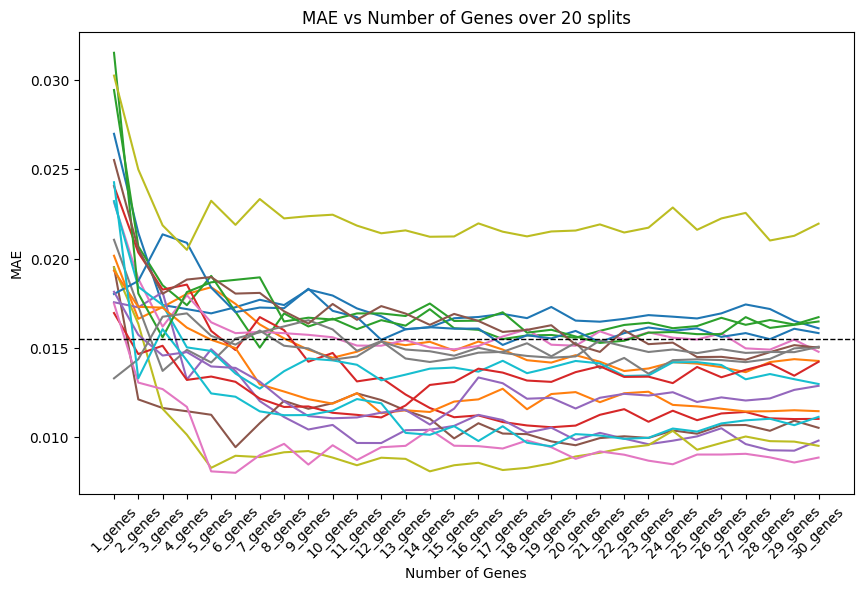

In [84]:
plt.figure(figsize=(10, 6))
for idx, row in mae_all_df.iterrows():
  plt.plot(mae_all_df.columns, row.values, label=idx)
plt.xlabel('Number of Genes')
plt.axhline(y=0.0155, color='black', linestyle='--', linewidth=1)
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.title('MAE vs Number of Genes over 20 splits')
plt.show()


We can see here that there is lots of variabilty between splits.  We can't get rid of the varibaility, but we can try to build a model that is as robust to this variability as possible.  First, let's look at the MAE for the average split.

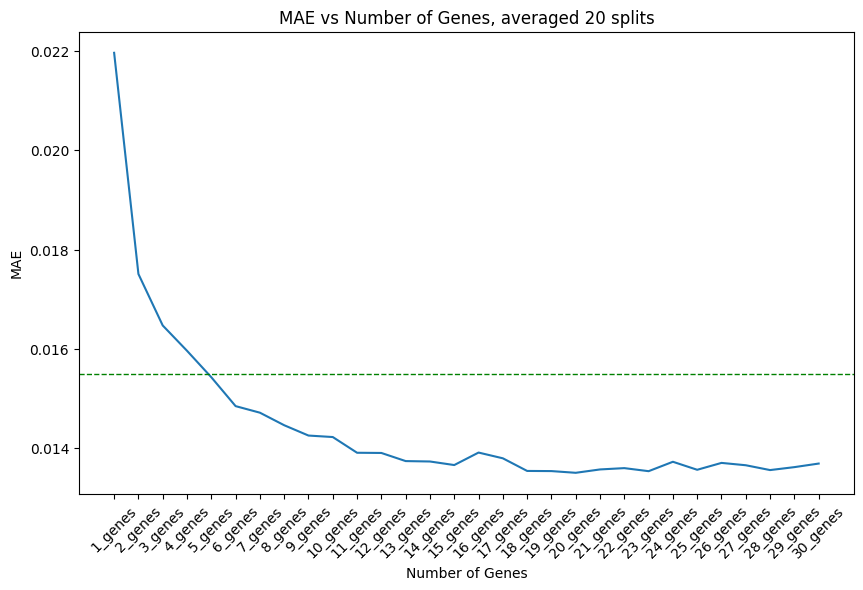

In [85]:
mae_all_mean = mae_all_df.mean(axis=0)
plt.figure(figsize=(10, 6))
plt.plot(mae_all_df.columns, mae_all_mean.values, label=idx)
plt.xlabel('Number of Genes')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.title('MAE vs Number of Genes, averaged 20 splits')
plt.show()

Out mean MAE is lowest at 6 genes but then stays low and moves around within the range of noise until 30 genes without going up.  This gives us some leeway - we don't have to get the number exact to have a reliable model.  This suggests that we have a fair amount of redundancy in our model - it might only take 20 genes to make predictions, but it's not always the same 20 genes. Not only that, the specific genes probably very from dataset to dataset, so picking a specific gene list might limit our ability to generalize this model.

To test this assumption, the next step is to see if the model picks the same genes with different splits.

In [86]:
from collections import Counter
def count_gene_use(selected_gene_dict):
  all_genes = []
  for genes in selected_gene_dict.values():
    all_genes.extend(genes)
  gene_counts = Counter(all_genes)
  df = pd.DataFrame.from_dict(gene_counts, orient='index', columns=['count'])
  return df.sort_values(by='count', ascending=False)

In [87]:
gene_counts_24_df = count_gene_use(selected_gene_24)
gene_counts_10_df = count_gene_use(selected_gene_10)
gene_counts_6_df = count_gene_use(selected_gene_6)

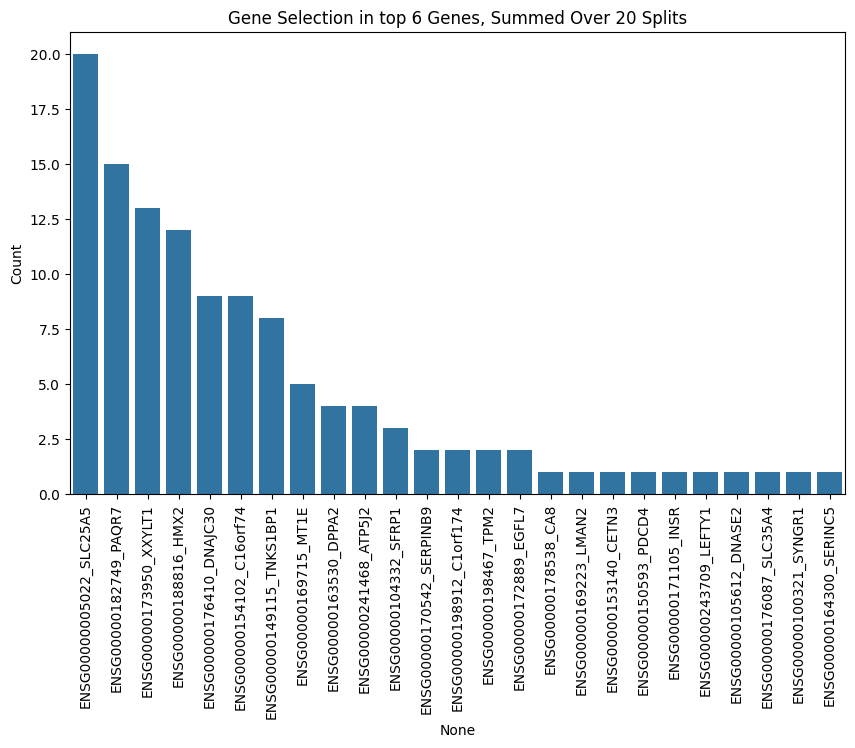

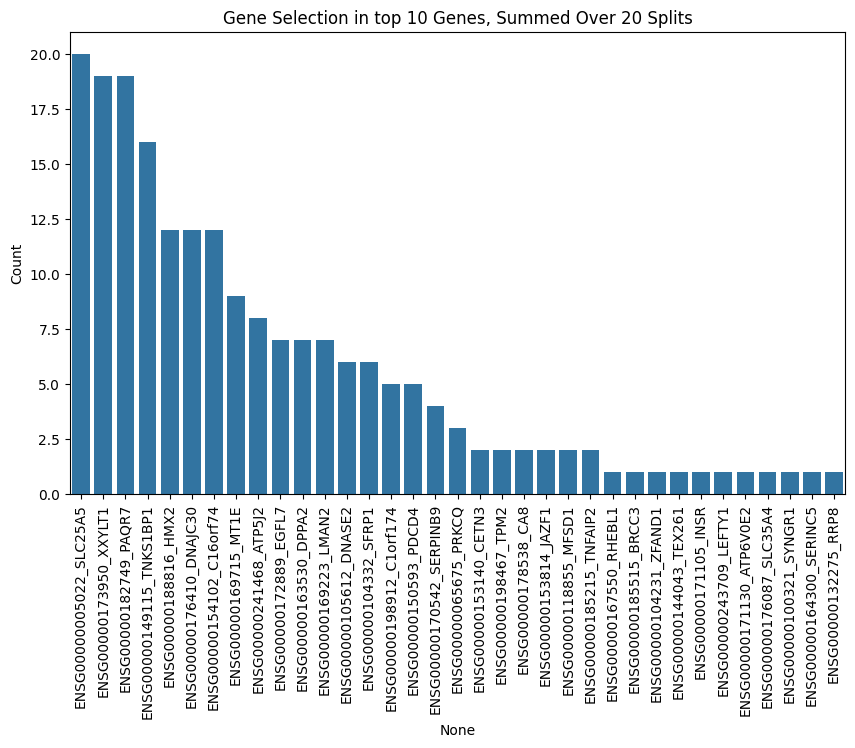

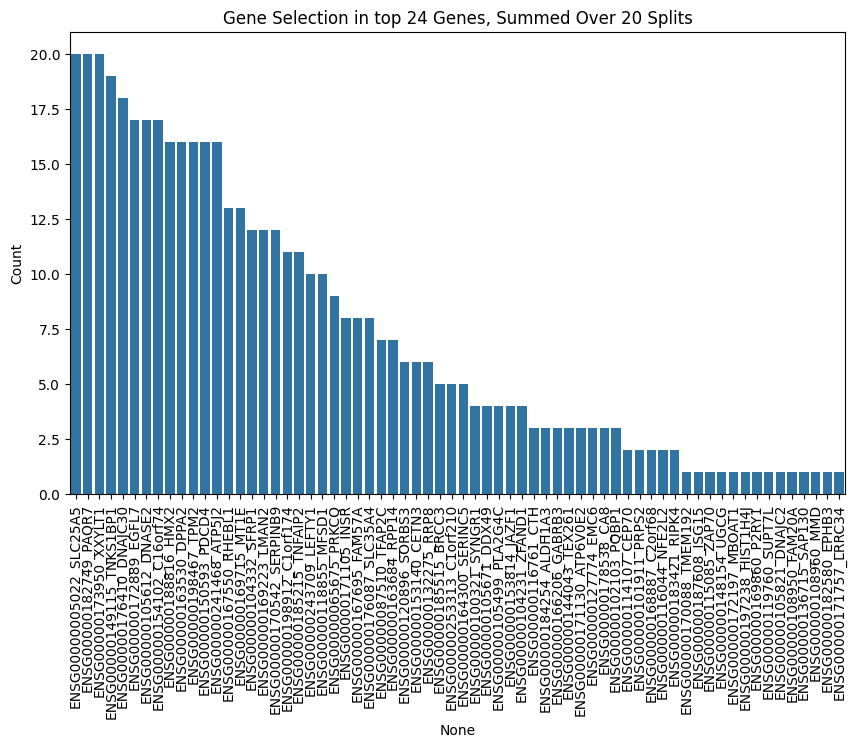

In [88]:
for k, group in [(6, gene_counts_6_df), (10, gene_counts_10_df), (24, gene_counts_24_df)]:
  plt.figure(figsize=(10, 6))
  sns.barplot(data=group, x=group.index, y='count')
  plt.title(f"Gene Selection in top {k} Genes, Summed Over 20 Splits")
  plt.ylabel("Count")
  plt.xticks(rotation=90)
  plt.show()

In [89]:
print(f'Number of genes in most important 24 genes over 20 splits: {gene_counts_24_df.shape[0]}')
print(f'Number of genes in most important 10 genes over 20 splits: {gene_counts_10_df.shape[0]}')
print(f'Number of genes in most important 6 genes over 20 splits: {gene_counts_6_df.shape[0]}')

Number of genes in most important 24 genes over 20 splits: 66
Number of genes in most important 10 genes over 20 splits: 35
Number of genes in most important 6 genes over 20 splits: 25


These results show us two things:

1) Out lists of 'top 6 genes' has 28 genes in it.  This confirms that there is redundancy in our model such that different sets of genes can be used to make predictions.
2) Some genes are more likely to be selected than others.  Some genes, like SLC25A5 are selected as being very important almost every time.  

Let's look at the overlap between the ~20 of genes most commonly in the top 24 and the genes in the top 10 or top 6.

In [90]:
top_22 = gene_counts_24_df[gene_counts_24_df['count'] >= 10]
common_10 = list(set(gene_counts_10_df.index) & set(top_22.index))
common_6 = list(set(gene_counts_6_df.index) & set(top_22.index))
print(f'Number of genes with 10+ selections in most important 24 genes: {len(top_22)}')
print(f'Number of common genes also in top 10 most important genes: {len(common_10)}')
print(f'Number of common genes also in top 6 most important genes: {len(common_6)}')

Number of genes with 10+ selections in most important 24 genes: 22
Number of common genes also in top 10 most important genes: 22
Number of common genes also in top 6 most important genes: 19


### Comparing Maual or Automated Gene Selection

This shows us that there is a group of 20 genes at the top that are selected most often.  Let's try building a model with just those 22 genes over multiple splits.

The above plots show our average model success if we allow the model to pick it's own genes for each split. The question is whether it is better to use a set of common genes (our top_22) or allow the model to select any 22 genes.  We will now compare these two options over 20 splits each.

First, with our definied list of 22 genes.

####Manual Gene Selection

In [91]:
top_22genes = list(top_22.index)
top_22genes

['ENSG00000005022_SLC25A5',
 'ENSG00000182749_PAQR7',
 'ENSG00000173950_XXYLT1',
 'ENSG00000149115_TNKS1BP1',
 'ENSG00000176410_DNAJC30',
 'ENSG00000172889_EGFL7',
 'ENSG00000105612_DNASE2',
 'ENSG00000154102_C16orf74',
 'ENSG00000188816_HMX2',
 'ENSG00000163530_DPPA2',
 'ENSG00000198467_TPM2',
 'ENSG00000150593_PDCD4',
 'ENSG00000241468_ATP5J2',
 'ENSG00000167550_RHEBL1',
 'ENSG00000169715_MT1E',
 'ENSG00000104332_SFRP1',
 'ENSG00000169223_LMAN2',
 'ENSG00000170542_SERPINB9',
 'ENSG00000198912_C1orf174',
 'ENSG00000185215_TNFAIP2',
 'ENSG00000243709_LEFTY1',
 'ENSG00000118855_MFSD1']

In [92]:
#Verify that donor_adata.layers["counts"] is still raw counts by finding the max value (should be large)
donor_adata.layers["counts"].max()

np.float64(4477677.06230918)

In [93]:
#Remake the dataset with the top 22 genes for safety
donor_rank_22 = donor_adata.copy()
donor_rank_22.X = donor_adata.layers["counts"]
donor_rank_22 = donor_adata[:, top_22genes].copy()

In [94]:
n_splits = 20
mae_all = {}
importances_dict = {}
X_22 = pd.DataFrame(donor_rank_22.X, columns=donor_rank_22.var_names, index=donor_rank_22.obs_names)
y_pr = donor_adata.obs['pseudorank']

for seed in range(n_splits):
  print(f"Starting seed {seed}")
  X_train, X_test, y_train, y_test = train_test_split(X_22, y_pr, test_size=0.2, random_state=seed) #Make Split
  X_train = normalize_log(X_train)
  X_test = normalize_log(X_test)
  full_model = CatBoostRegressor(verbose=0) #Fit full model
  full_model.fit(X_train, y_train)
  importances = full_model.get_feature_importance()
  importances_series = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
  importances_dict[seed] = pd.Series(100 * importances / importances.sum(), index=X_train.columns).sort_values(ascending=False)
  mae_split = []
  for i in range(1, 23, 1):
    selected_features = importances_series.head(i).index #Select top k genes
    X_train_short = X_train[selected_features]
    X_test_short = X_test[selected_features]
    model = CatBoostRegressor(verbose=0)
    model.fit(X_train_short, y_train)
    y_pred = model.predict(X_test_short)
    mae = mean_absolute_error(y_test, y_pred) #collect MAE
    mae_split.append(mae)
  mae_all[seed] = mae_split

Starting seed 0
Starting seed 1
Starting seed 2
Starting seed 3
Starting seed 4
Starting seed 5
Starting seed 6
Starting seed 7
Starting seed 8
Starting seed 9
Starting seed 10
Starting seed 11
Starting seed 12
Starting seed 13
Starting seed 14
Starting seed 15
Starting seed 16
Starting seed 17
Starting seed 18
Starting seed 19


In [95]:
mae_22_df = pd.DataFrame.from_dict(mae_all, orient='index')
mae_22_df.index = [f"split_{i+1}" for i in mae_22_df.index]
mae_22_df.columns = [f"{i+1}_genes" for i in range(22)]

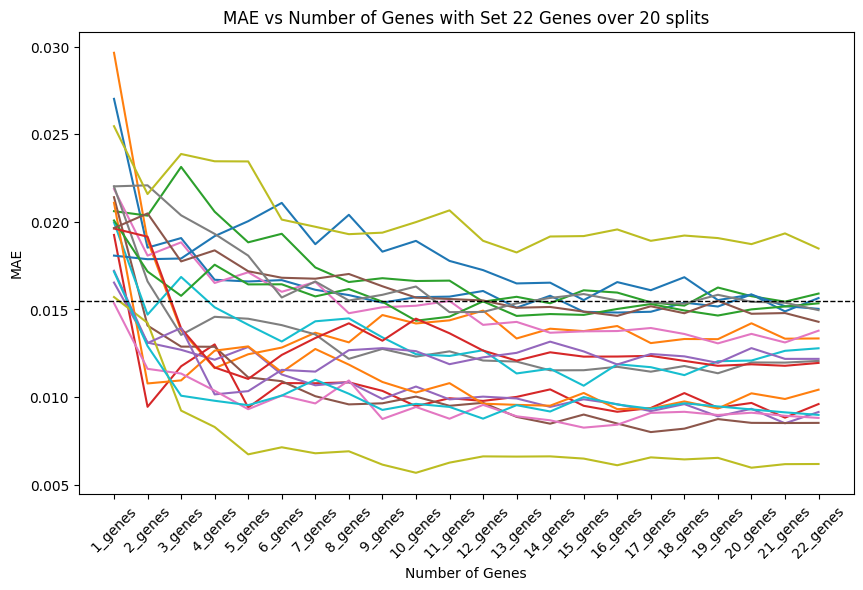

In [96]:
plt.figure(figsize=(10, 6))
for idx, row in mae_22_df.iterrows():
  plt.plot(mae_22_df.columns, row.values, label=idx)
plt.xlabel('Number of Genes')
plt.axhline(y=0.0155, color='black', linestyle='--', linewidth=1)
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.title('MAE vs Number of Genes with Set 22 Genes over 20 splits')
plt.show()


We can also look at the relative importance of each gene, averaged over the 20 splits.

In [97]:
importances_df = pd.DataFrame.from_dict(importances_dict)
importances_df_mean = importances_df.mean(axis=1).sort_values(ascending=False)
importances_df_mean


,0
Unnamed: 0,
ENSG00000176410_DNAJC30,13.196282
ENSG00000188816_HMX2,7.713874
ENSG00000198467_TPM2,6.927733
ENSG00000149115_TNKS1BP1,6.463602
ENSG00000154102_C16orf74,5.860298
ENSG00000169715_MT1E,5.281428
ENSG00000170542_SERPINB9,5.062366
ENSG00000173950_XXYLT1,4.964286
ENSG00000005022_SLC25A5,4.848637


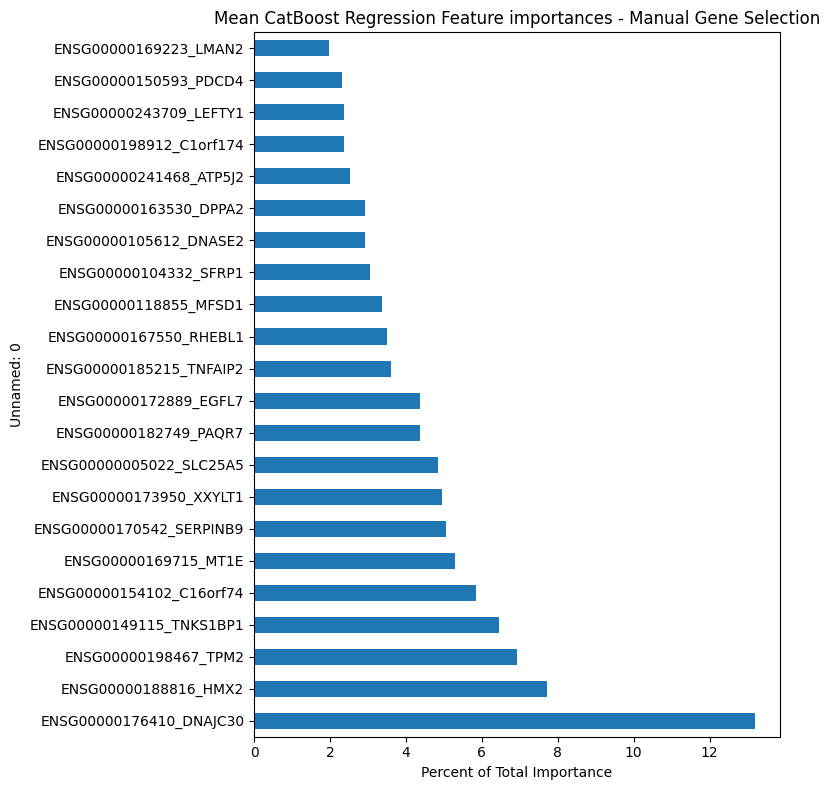

In [98]:
#Plot feature importances
fig, ax = plt.subplots(figsize=(8,8))
importances_df_mean.plot.barh(ax=ax)
ax.set_title("Mean CatBoost Regression Feature importances - Manual Gene Selection")
ax.set_xlabel("Percent of Total Importance")
fig.tight_layout()
plt.show()

####Automated Gene Selection

Now let's try again with setting the model to pick any 22 genes from out list of 100.

In [99]:
#Verify that donor_rank_100.layers["counts"] is still raw counts by finding the max value (should be large)
donor_rank_100.layers["counts"].max()

np.float64(759411.0718874728)

In [100]:
n_splits = 20
shap_threshold = .0005
mae_all = {}
importances_dict = {}
donor_rank_100_V2 = donor_rank_100.copy()
donor_rank_100_V2.X = donor_rank_100_V2.layers["counts"]
#I had to move the normalization out of the loop and switch back the Scanpy based normalization to prevent the code from hanging.
#Normalization is by row, so no data leakage will occur.
sc.pp.normalize_total(donor_rank_100_V2, target_sum=1e4)
sc.pp.log1p(donor_rank_100_V2)
X_100 = pd.DataFrame(donor_rank_100_V2.X, columns=donor_rank_100_V2.var_names, index=donor_rank_100_V2.obs_names)
y_pr = donor_adata.obs['pseudorank']

for seed in range(n_splits):
  X_train, X_test, y_train, y_test = train_test_split(X_100, y_pr, test_size=0.2, random_state=seed) #Make Split
  train_pool = Pool(X_train, y_train)
  selector_model = CatBoostRegressor(loss_function = 'MAE', verbose=0) #Fit full model
  selector_model.fit(X_train, y_train)
  shap_values = selector_model.get_feature_importance(data=train_pool, type='ShapValues') #Calculate shap values
  feature_importance = np.abs(shap_values).mean(axis=0) #Calculate feature importance
  sorted_features = sorted(zip(X_train.columns, feature_importance), key=lambda x: x[1], reverse=True)
  selected_genes = [f for f,val in zip(X_train.columns, feature_importance) if val > shap_threshold] #fine genes above threshold
  selected_genes = selected_genes[:22]
  if len(selected_genes) == 0:
    selected_genes = [f for f, _ in sorted_features[:5]]
  importances_dict[seed] = sorted_features[:22]
  mae_split = []
  for i in range(1, 23, 1):
    selected_features_short = selected_genes[:i] #Select top k genes
    X_train_short = X_train[selected_features_short]
    X_test_short = X_test[selected_features_short]
    model = CatBoostRegressor(verbose=0)
    model.fit(X_train_short, y_train)
    y_pred = model.predict(X_test_short)
    mae = mean_absolute_error(y_test, y_pred) #collect MAE
    mae_split.append(mae)
  mae_all[seed] = mae_split

Note: I am aware of the warning that adata.X has already been normalized. This was thoroughly investigated and the data is still in the orignal form that was found on the raw_counts.csv file. I think the warning is being triggered by the decimal points that are not normally present in raw RNAseq data, but this is most likely present due to some step quaility control step by Cuomo et al.

In [101]:
mae_auto_df = pd.DataFrame.from_dict(mae_all, orient='index')
mae_auto_df.index = [f"split_{i+1}" for i in mae_auto_df.index]
mae_auto_df.columns = [f"{i+1}_genes" for i in range(22)]

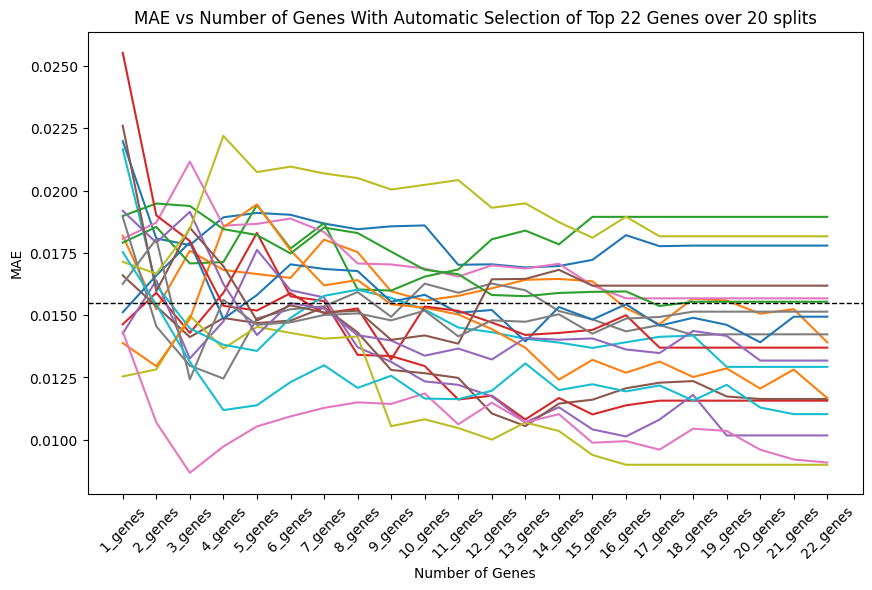

In [102]:
plt.figure(figsize=(10, 6))
for idx, row in mae_auto_df.iterrows():
  plt.plot(mae_auto_df.columns, row.values, label=idx)
plt.xlabel('Number of Genes')
plt.axhline(y=0.0155, color='black', linestyle='--', linewidth=1)
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.title('MAE vs Number of Genes With Automatic Selection of Top 22 Genes over 20 splits')
plt.show()


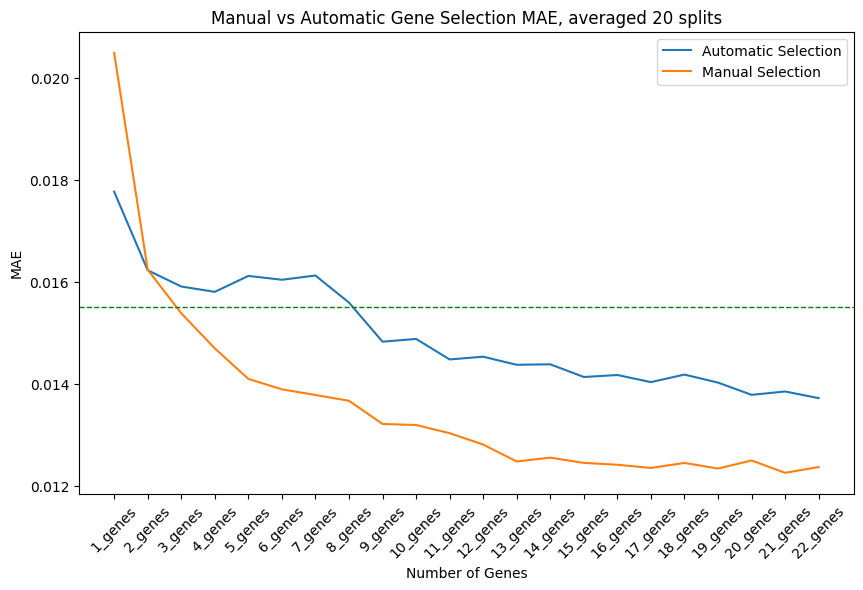

In [103]:
mae_22_mean = mae_22_df.mean(axis=0)
mae_auto_mean = mae_auto_df.mean(axis=0)
plt.figure(figsize=(10, 6))
plt.plot(mae_auto_df.columns, mae_auto_mean.values, label='Automatic Selection')
plt.plot(mae_22_df.columns, mae_22_mean.values, label='Manual Selection')
plt.xlabel('Number of Genes')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.axhline(y=0.0155, color='green', linestyle='--', linewidth=1)
plt.title('Manual vs Automatic Gene Selection MAE, averaged 20 splits')
plt.legend()
plt.show()

In [104]:
importances_df_auto = pd.DataFrame.from_dict(importances_dict)
importances_df_auto_mean = importances_df.mean(axis=1).sort_values(ascending=False)

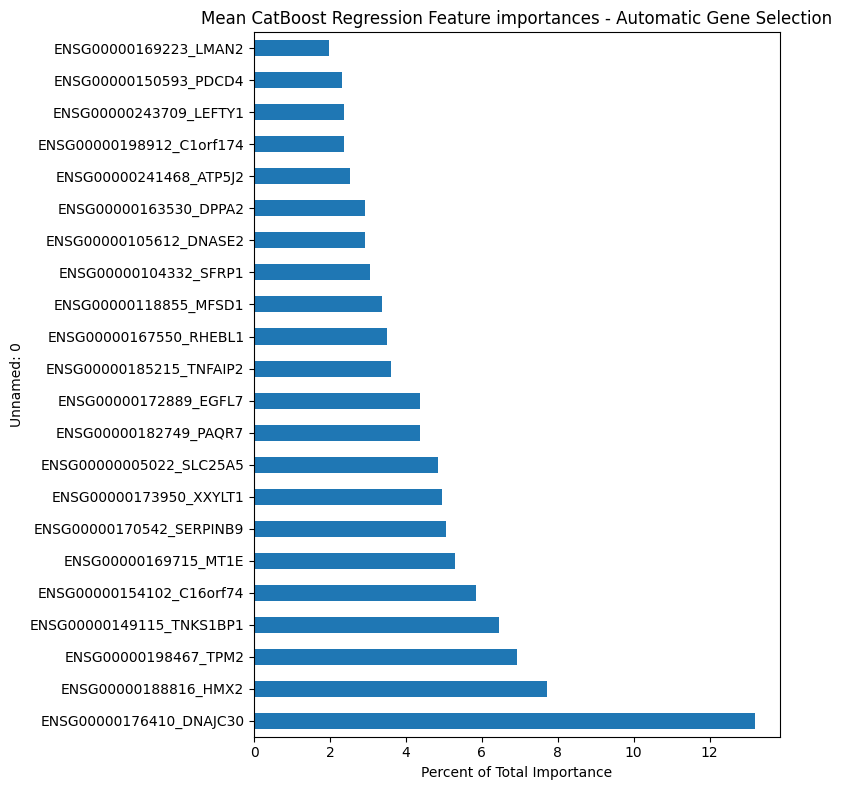

In [105]:
#Plot feature importances
fig, ax = plt.subplots(figsize=(8,8))
importances_df_auto_mean.plot.barh(ax=ax)
ax.set_title("Mean CatBoost Regression Feature importances - Automatic Gene Selection")
ax.set_xlabel("Percent of Total Importance")
fig.tight_layout()
plt.show()

This comparison between manually selecting specific genes and letting the model automatically select genes for each split shows us that we get a lower error when we manually choose the genes if we use 7 or more genes. If we wanted to use fewer than 7 genes, the automatic selection is superior.

This does not mean that manual gene selection makes the best model for new data. New data will be from different RNAseq batches and might get better predictions from a different set of genes than what we used here. Without testing this on new datasets, using manual selection in our final model is risky. I recommend making a model that is based on our 22 genes, and a model able to do gene selction based on the specifics of the new dataset.

##Final Model

In our final model, we must build something that will be as reslient as possible to differences between new datasets, even if that means sacrificing MAE with the existing dataset.  For that reason, I will use recursive feature elimination to select genes based on the split, rather than using the genes we have already identified for our split with random state 42.

In [ ]:
#Final Model with Manual Gene Selection
X_22 = pd.DataFrame(donor_rank_22.X, columns=donor_rank_22.var_names, index=donor_rank_22.obs_names)
y_pr = donor_adata.obs['pseudorank']

X_train, X_test, y_train, y_test = train_test_split(X_22, y_pr, test_size=0.2, random_state=seed)
X_train = normalize_log(X_train)
X_test = normalize_log(X_test)
CB_final_manual = CatBoostRegressor(verbose=0)
CB_final_manual.fit(X_train, y_train)
y_pred_manual = CB_final_manual.predict(X_test)
mae_manual = mean_absolute_error(y_test, y_pred_manual )

In [ ]:
X_100 = pd.DataFrame(donor_rank_100.X, columns=donor_rank_100.var_names, index=donor_rank_100.obs_names)
y_pr = donor_adata.obs['pseudorank']
shap_threshold = .0005

X_train, X_test, y_train, y_test = train_test_split(X_100, y_pr, test_size=0.2, random_state=seed) #Perform Split
X_train = normalize_log(X_train)
X_test = normalize_log(X_test)

train_pool = Pool(X_train, y_train)
selector_model = CatBoostRegressor(loss_function = 'MAE', verbose=0) #Build Selector Model for calculating Shap Values
selector_model.fit(X_train, y_train)
shap_values = selector_model.get_feature_importance(data=train_pool, type='ShapValues') #Calculate shap values
feature_importance = np.abs(shap_values).mean(axis=0) #Calculate feature importance
sorted_features = sorted(zip(X_train.columns, feature_importance), key=lambda x: x[1], reverse=True)
selected_genes = [f for f,val in zip(X_train.columns, feature_importance) if val > shap_threshold] #fine genes above threshold
selected_genes = selected_genes[:22]
if len(selected_genes) == 0:
  selected_genes = [f for f, _ in sorted_features[:5]]
CB_final_auto = CatBoostRegressor(loss_function = 'MAE', verbose=0) #train new model on selected_genes
CB_final_auto.fit(X_train[selected_genes], y_train)
y_pred_auto = CB_final_auto.predict(X_test[selected_genes])
mae_auto = mean_absolute_error(y_test, y_pred_auto)

In [ ]:
print(f'MAE for Manual Gene Selection: {mae_manual}')
print(f'MAE for Automatic Gene Selection: {mae_auto}')

MAE for Manual Gene Selection: 0.009139791180862196
MAE for Automatic Gene Selection: 0.009567536456934825


In [ ]:
#Save final dataset used for manual and automatic models
donor_rank_100.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/donor_100_automatic.h5ad")
donor_rank_22.write_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/donor_22_manual.h5ad")

In [ ]:
CB_final_manual.save_model("/content/drive/MyDrive/Springboard/Capstone3_iPSC/CB_final_manual.cbm")
CB_final_auto.save_model("/content/drive/MyDrive/Springboard/Capstone3_iPSC/CB_final_automatic.cbm")